# DreamBooth LoRA Fine-tuning Assignment

**Total Points: 100** (Plus 10 Bonus Points)

In this assignment, you will implement key components of the **DreamBooth** technique using **LoRA (Low-Rank Adaptation)** to fine-tune a Stable Diffusion model.

## Theoretical Background

### 1. DreamBooth
DreamBooth is a fine-tuning technique designed to teach a text-to-image model about a specific subject (e.g., a specific person, dog, or object) using only a few images (typically 3-5).

**Key Concepts:**
*   **Rare Token Identifier**: We bind the subject to a unique identifier in the prompt, often a rare token sequence like "sks". For example, "a photo of a sks dog". This avoids colliding with the model's existing knowledge of "dog".
*   **Prior Preservation**: A major challenge in fine-tuning on small datasets is *overfitting* and *language drift*. The model might learn your "sks dog" perfectly but forget what a generic "dog" looks like.
    *   **Solution**: We use a **Prior Preservation Loss**. We generate images of the generic class (e.g., "a photo of a dog") using the frozen pre-trained model. These are key "Class Images".
    *   **Loss Function**: The total loss is a weighted sum of the reconstruction loss on your specific instance images and the reconstruction loss on the generated class images. This forces the model to retain its prior knowledge.

### 2. LoRA (Low-Rank Adaptation)
Fine-tuning the entire UNet (billions of parameters) is computationally expensive and storage-heavy. **LoRA** offers a parameter-efficient alternative.

**How it works:**
Instead of updating the full weight matrix $W$, LoRA freezes $W$ and injects trainable rank decomposition matrices.
*   Hypothesis: The change in weights $\Delta W$ during adaptation has a low "intrinsic rank".
*   Decomposition: $\Delta W = B \cdot A$, where $B \in \mathbb{R}^{d 	imes r}$ and $A \in \mathbb{R}^{r 	imes k}$.
    *   $r$ is the **rank**, a hyperparameter (e.g., 4 or 8), which is much smaller than the model dimension $d$.
*   Forward Pass: $h = W_0 x + \Delta W x = W_0 x + B A x$.
*   **Result**: We only train $A$ and $B$, reducing trainable parameters by up to 10,000x compared to full fine-tuning.

---

## Objectives & Grading
1.  **Part 1: Data Preparation** (5 Points)
    *   Setup custom dataset.
2.  **Part 2: Dataset Class** (35 Points)
    *   Implement data loading and tokenization.
3.  **Part 3: Training Loop** (35 Points)
    *   Implement noise sampling and loss computation.
4.  **Part 4: Inference & Analysis** (25 Points)
    *   Experiment with inference parameters.
5.  **Bonus: Prior Preservation** (10 Points)
    *   Generate class images.



## 1. Setup and Installation

We install `diffusers`, `transformers`, `accelerate`, and `peft` (Parameter-Efficient Fine-Tuning).



In [1]:
!pip uninstall -y torch torchvision torchaudio fastai
!pip install torch torchvision torchaudio
!pip install diffusers transformers accelerate peft bitsandbytes

Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
Found existing installation: torchvision 0.25.0
Uninstalling torchvision-0.25.0:
  Successfully uninstalled torchvision-0.25.0
Found existing installation: torchaudio 2.10.0
Uninstalling torchaudio-2.10.0:
  Successfully uninstalled torchaudio-2.10.0
Found existing installation: fastai 2.8.6
Uninstalling fastai-2.8.6:
  Successfully uninstalled fastai-2.8.6
  Using cached torch-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached torchaudio-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
Using cached torch-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl (915.7 MB)
Using cached torchvision-0.25.0-cp312-cp312-manylinux_2_28_x86_64.whl (8.1 MB)
Using cached torchaudio-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl (1.9 MB)


In [2]:
import torch
import torchvision
import transformers
from diffusers import StableDiffusionPipeline

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA Available: True


In [3]:
import argparse
import copy
import gc
import logging
import math
import os
import shutil
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import torch.utils.checkpoint
import transformers
from accelerate import Accelerator
from accelerate.logging import get_logger
from accelerate.utils import ProjectConfiguration, set_seed
from huggingface_hub.utils import insecure_hashlib
from packaging import version
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict, set_peft_model_state_dict
from PIL import Image
from PIL.ImageOps import exif_transpose
from torch.utils.data import Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from transformers import AutoTokenizer, PretrainedConfig

import diffusers
from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    DiffusionPipeline,
    DPMSolverMultistepScheduler,
    StableDiffusionPipeline,
    UNet2DConditionModel,
)
from diffusers.loaders import LoraLoaderMixin
from diffusers.optimization import get_scheduler
from diffusers.training_utils import _set_state_dict_into_text_encoder, cast_training_params
from diffusers.utils import (
    check_min_version,
    convert_state_dict_to_diffusers,
    convert_unet_state_dict_to_peft,
    is_wandb_available,
)
from diffusers.utils.import_utils import is_xformers_available
from diffusers.utils.torch_utils import is_compiled_module

logger = get_logger(__name__)


## 2. Configuration & Data Preparation (Part 1: 5 Points)

**Instructions:**
1.  **Select a Subject**: Choose a subject (e.g., your pet, a toy, yourself).
2.  **Collect Images**: Take or gather **5 original images** of this subject.
    *   *Requirement*: Images should be **consistent** (same subject). Varying backgrounds is good but keep the subject clearly visible.
3.  **Upload**: Run the cell below to create the folder, then manually upload your images to `./instance_data`.
4.  **Configure**: Update `instance_prompt`, `class_prompt`, and `validation_prompt` in the config below.

**Note on Hyperparameters**:
*   `max_train_steps=1000`: Sufficient for LoRA to learn the subject.
*   `train_text_encoder = True`: We train the text encoder (CLIP) to better learn the prompt association (e.g., "sks cat").



In [5]:
class TrainingConfig:
    pretrained_model_name_or_path = "runwayml/stable-diffusion-v1-5"
    instance_data_dir = "./instance_data"
    class_data_dir = "./class_data"
    output_dir = "./lora-dreambooth-model"

    # STUDENT TODO: Update these prompts for your specific subject
    instance_prompt = "a photo of a sks boot"      # Unique identifier 'sks'
    class_prompt = "a photo of a boot"             # Generic class
    validation_prompt = "a photo of a sks boot on the moon" # Test prompt

    seed = 42
    resolution = 512
    center_crop = True
    train_text_encoder = True  # Enable to improve prompt fidelity
    train_batch_size = 1
    sample_batch_size = 4
    num_train_epochs = 10      # Increased for better convergence
    max_train_steps = 1000
    checkpointing_steps = 250
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_scheduler = "constant"
    lr_warmup_steps = 0
    use_8bit_adam = True
    mixed_precision = "fp16"
    rank = 4
    with_prior_preservation = True
    prior_loss_weight = 1.0
    num_class_images = 100
    max_grad_norm = 1.0        # Gradient clipping

    # Validation settings
    num_validation_images = 4
    validation_epochs = 50
    validation_images = None

    # Misc
    logging_dir = "logs"
    report_to = "tensorboard"
    allow_tf32 = False
    local_rank = -1
    enable_xformers_memory_efficient_attention = True
    pre_compute_text_embeddings = False
    tokenizer_max_length = None
    text_encoder_use_attention_mask = False
    class_labels_conditioning = None

args = TrainingConfig()

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
    args.mixed_precision = "no"
    print("CUDA not available. Switched mixed_precision to 'no'.")


In [6]:
import os
from pathlib import Path

if not os.path.exists(args.instance_data_dir):
    os.makedirs(args.instance_data_dir)
    print(f"Created directory {args.instance_data_dir}. Please upload your 5 images here.")

if not os.path.exists(args.class_data_dir):
    os.makedirs(args.class_data_dir)

# Helper function to display a grid of images
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols
    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid


Created directory ./instance_data. Please upload your 5 images here.


## Bonus: Prior Preservation (10 Points)

**The Problem**: If we only train on "sks dog", the model might forget what other normal dogs look like.
**The Solution**: We enable `with_prior_preservation`. We must provide generated images of generic dogs in `class_data_dir`. The model will calculate loss on these too, ensuring it still knows how to generate generic dogs.

**Bonus Task**: Write or run the code below to generate `num_class_images` (e.g. 100) using the `class_prompt` using the pre-trained model.
*Hint*: Use `StableDiffusionPipeline` to generate images and save them to `args.class_data_dir`.



In [7]:
# BONUS TODO: Implement Class Image Generation
import torch
from diffusers import StableDiffusionPipeline
from tqdm.auto import tqdm

# 1. Check if class images exist
if not os.path.exists(args.class_data_dir):
    os.makedirs(args.class_data_dir)

cur_class_images = len(list(Path(args.class_data_dir).iterdir()))

# 2. If missing, generate args.num_class_images
if cur_class_images < args.num_class_images:
    print(f"Generating class images... ({cur_class_images}/{args.num_class_images})")

    # Load pipeline just for this step
    pipe = StableDiffusionPipeline.from_pretrained(
        args.pretrained_model_name_or_path,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
    )
    pipe.to(device)
    pipe.set_progress_bar_config(disable=True)

    num_new_images = args.num_class_images - cur_class_images

    for i in tqdm(range(num_new_images)):
        # Generate image using the GENERIC prompt
        image = pipe(args.class_prompt).images[0]

        # Save to class_data_dir
        image.save(os.path.join(args.class_data_dir, f"class_{cur_class_images + i}.jpg"))

    # Free up memory
    del pipe
    torch.cuda.empty_cache()
    import gc
    gc.collect()
else:
    print("Class images already exist.")

Generating class images... (0/100)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/100 [00:00<?, ?it/s]

## Part 2: Dataset Class (35 Points)

We need a PyTorch `Dataset` to handle our images.

**Detailed Algorithm**:
1.  **Instance Data**: We read an image $x$, resize/crop it to $512 \times 512$, and normalize it to $[-1, 1]$. We also tokenize the prompt (e.g., "a photo of a sks dog") into `input_ids`.
2.  **Class Data (Prior Preservation)**: If enabled, we also load a random image from the `class_data_dir` and tokenize the class prompt (e.g., "a photo of a dog").
3.  **Return**: The dataset `__getitem__` returns a dictionary containing both instance and (optional) class examples.

**Task**: Complete the `__getitem__` method.



In [8]:
def tokenize_prompt(tokenizer, prompt, tokenizer_max_length=None):
    if tokenizer_max_length is not None:
        max_length = tokenizer_max_length
    else:
        max_length = tokenizer.model_max_length

    text_inputs = tokenizer(
        prompt,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt",
    )

    return text_inputs


In [9]:
class DreamBoothDataset(Dataset):
    def __init__(
        self,
        instance_data_root,
        instance_prompt,
        tokenizer,
        class_data_root=None,
        class_prompt=None,
        class_num=None,
        size=512,
        center_crop=False,
        encoder_hidden_states=None,
        class_prompt_encoder_hidden_states=None,
        tokenizer_max_length=None,
    ):
        self.size = size
        self.center_crop = center_crop
        self.tokenizer = tokenizer
        self.encoder_hidden_states = encoder_hidden_states
        self.class_prompt_encoder_hidden_states = class_prompt_encoder_hidden_states
        self.tokenizer_max_length = tokenizer_max_length

        self.instance_data_root = Path(instance_data_root)
        if not self.instance_data_root.exists():
            raise ValueError("Instance images root doesn't exists.")

        self.instance_images_path = list(Path(instance_data_root).iterdir())
        self.num_instance_images = len(self.instance_images_path)
        self.instance_prompt = instance_prompt
        self._length = self.num_instance_images

        if class_data_root is not None:
            self.class_data_root = Path(class_data_root)
            self.class_data_root.mkdir(parents=True, exist_ok=True)
            self.class_images_path = list(self.class_data_root.iterdir())
            if class_num is not None:
                self.num_class_images = min(len(self.class_images_path), class_num)
            else:
                self.num_class_images = len(self.class_images_path)
            self._length = max(self.num_class_images, self.num_instance_images)
            self.class_prompt = class_prompt
        else:
            self.class_data_root = None

        self.image_transforms = transforms.Compose(
            [
                transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
                transforms.ToTensor(),
                transforms.Normalize([0.5], [0.5]),
            ]
        )

    def __len__(self):
        return self._length

    def __getitem__(self, index):
        example = {}

        # STUDENT TODO: Implement Instance Loading
        # 1. Open image
        instance_image = Image.open(self.instance_images_path[index % self.num_instance_images])
        if not instance_image.mode == "RGB":
            instance_image = instance_image.convert("RGB")

        # 2. Apply transforms
        example["instance_images"] = self.image_transforms(instance_image)

        # 3. Tokenize instance prompt
        example["instance_prompt_ids"] = self.tokenizer(
            self.instance_prompt,
            truncation=True,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        ).input_ids

        # STUDENT TODO: Prior Preservation Loading
        if self.class_data_root:
            class_image = Image.open(self.class_images_path[index % self.num_class_images])
            if not class_image.mode == "RGB":
                class_image = class_image.convert("RGB")

            example["class_images"] = self.image_transforms(class_image)
            example["class_prompt_ids"] = self.tokenizer(
                self.class_prompt,
                truncation=True,
                padding="max_length",
                max_length=self.tokenizer.model_max_length,
                return_tensors="pt",
            ).input_ids

        return example


In [10]:
def collate_fn(examples, with_prior_preservation=False):
    has_attention_mask = "instance_attention_mask" in examples[0]

    input_ids = [example["instance_prompt_ids"] for example in examples]
    pixel_values = [example["instance_images"] for example in examples]

    if has_attention_mask:
        attention_mask = [example["instance_attention_mask"] for example in examples]

    if with_prior_preservation:
        input_ids += [example["class_prompt_ids"] for example in examples]
        pixel_values += [example["class_images"] for example in examples]
        if has_attention_mask:
            attention_mask += [example["class_attention_mask"] for example in examples]

    pixel_values = torch.stack(pixel_values)
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()

    input_ids = torch.cat(input_ids, dim=0)

    batch = {
        "input_ids": input_ids,
        "pixel_values": pixel_values,
    }

    if has_attention_mask:
        batch["attention_mask"] = attention_mask

    return batch


## 5. Model Loading

We load the `StableDiffusionPipeline` components.

### Understanding Stable Diffusion
Stable Diffusion is a **Latent Diffusion Model (LDM)**. Unlike standard diffusion models that operate in pixel space (which is computationally expensive), LDMs operate in a compressed **latent space**.

**Architecture Components:**
1.  **VAE (Variational Autoencoder)**:
    *   **Encoder**: Compresses the image $x$ into a smaller latent representation $z = \mathcal{E}(x)$ (e.g. $512 \times 512 \rightarrow 64 \times 64$).
    *   **Decoder**: Reconstructs the image from latents $\hat{x} = \mathcal{D}(z)$.
    *   *Role*: Moves the diffusion process from high-dimensional pixels to low-dimensional latents.
2.  **UNet**:
    *   The core "denoising" engine. It takes a noisy latent $z_t$, the timestep $t$, and text embeddings $c$ as input, and predicts the noise $\epsilon$.
    *   *Role*: Learns to reverse the diffusion process.
3.  **Text Encoder (CLIP)**:
    *   Tokenizes and encodes the text prompt into embeddings.
    *   *Role*: Guides the UNet via cross-attention layers.
4.  **Scheduler**:
    *   Controls the noise schedule (how much noise is added at each step) and the sampling algorithm (how to subtract noise during inference).

**Diagram:**

![Stable Diffusion Architecture](sd_architecture.png)

### LoRA Setup
We create a `LoraConfig`. Note the `target_modules` (query, value, key projections in attention layers). We attach these small adapters to the frozen UNet.



In [11]:
def import_model_class_from_model_name_or_path(pretrained_model_name_or_path: str, revision: str):
    text_encoder_config = PretrainedConfig.from_pretrained(
        pretrained_model_name_or_path,
        subfolder="text_encoder",
        revision=revision,
    )
    model_class = text_encoder_config.architectures[0]
    if model_class == "CLIPTextModel":
        from transformers import CLIPTextModel
        return CLIPTextModel
    else:
        raise ValueError(f"{model_class} is not supported.")

def encode_prompt(text_encoder, input_ids, attention_mask, text_encoder_use_attention_mask=None):
    text_input_ids = input_ids.to(text_encoder.device)

    if text_encoder_use_attention_mask:
        attention_mask = attention_mask.to(text_encoder.device)
    else:
        attention_mask = None

    prompt_embeds = text_encoder(
        text_input_ids,
        attention_mask=attention_mask,
        return_dict=False,
    )
    prompt_embeds = prompt_embeds[0]
    return prompt_embeds


## Part 3: Training Loop (35 Points)

**Algorithm Detail**:
Standard Diffusion Training:
1.  **Latents**: Encode image $x$ to latent $z_0 = \mathcal{E}(x)$.
2.  **Noise**: Sample gaussian noise $\epsilon \sim \mathcal{N}(0, I)$ and timestep $t$.
3.  **Forward Diffusion**: Add noise to get $z_t = \sqrt{\bar{\alpha}_t}z_0 + \sqrt{1-\bar{\alpha}_t}\epsilon$.
4.  **Prediction**: The model predicts the noise: $\epsilon_\theta(z_t, t, c)$, where $c$ is the text embedding.
5.  **Loss**: $L = ||\epsilon - \epsilon_\theta(z_t, t, c)||^2$.

**Task**: Implement steps 2, 3, 4, 5 inside the loop.



In [12]:
def training_loop(args, accelerator, unet, text_encoder, vae, noise_scheduler, optimizer, train_dataloader, lr_scheduler):

    weight_dtype = torch.float32
    if accelerator.mixed_precision == "fp16":
        weight_dtype = torch.float16
    elif accelerator.mixed_precision == "bf16":
        weight_dtype = torch.bfloat16

    global_step = 0

    progress_bar = tqdm(range(args.max_train_steps), disable=not accelerator.is_local_main_process)
    progress_bar.set_description("Steps")

    for epoch in range(args.num_train_epochs):
        unet.train()
        if args.train_text_encoder:
            text_encoder.train()

        for step, batch in enumerate(train_dataloader):
            with accelerator.accumulate(unet):
                pixel_values = batch["pixel_values"].to(dtype=weight_dtype)

                if vae is not None:
                    # Convert images to latent space
                    model_input = vae.encode(pixel_values).latent_dist.sample()
                    model_input = model_input * vae.config.scaling_factor
                else:
                    model_input = pixel_values

                bsz = model_input.shape[0]
                timesteps = torch.randint(
                    0, noise_scheduler.config.num_train_timesteps, (bsz,), device=model_input.device
                )
                timesteps = timesteps.long()

                encoder_hidden_states = encode_prompt(
                    text_encoder,
                    batch["input_ids"],
                    batch.get("attention_mask", None),
                    text_encoder_use_attention_mask=args.text_encoder_use_attention_mask,
                )

                # ==========================================
                # STUDENT TODO: Forward Pass & Loss
                # ==========================================

                # 1. Sample noise
                noise = torch.randn_like(model_input)

                # 2. Add noise to model_input (Forward Diffusion)
                noisy_model_input = noise_scheduler.add_noise(model_input, noise, timesteps)

                # 3. Predict noise (unet)
                model_pred = unet(noisy_model_input, timesteps, encoder_hidden_states).sample

                # Get the target for loss (usually the noise itself)
                if noise_scheduler.config.prediction_type == "epsilon":
                    target = noise
                elif noise_scheduler.config.prediction_type == "v_prediction":
                    target = noise_scheduler.get_velocity(model_input, noise, timesteps)
                else:
                    raise ValueError(f"Unknown prediction type {noise_scheduler.config.prediction_type}")

                # 4. Compute Loss (MSE) with Prior Preservation weighting
                if args.with_prior_preservation:
                    # Split the batch: first half is instance, second half is class
                    model_pred, model_pred_prior = torch.chunk(model_pred, 2, dim=0)
                    target, target_prior = torch.chunk(target, 2, dim=0)

                    # Calculate instance loss
                    loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")

                    # Calculate prior loss
                    prior_loss = F.mse_loss(model_pred_prior.float(), target_prior.float(), reduction="mean")

                    # Combine losses
                    loss = loss + args.prior_loss_weight * prior_loss
                else:
                    loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")

                # ==========================================

                accelerator.backward(loss)
                if accelerator.sync_gradients:
                    accelerator.clip_grad_norm_(unet.parameters(), args.max_grad_norm)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            if accelerator.sync_gradients:
                progress_bar.update(1)
                global_step += 1

                if global_step % args.checkpointing_steps == 0:
                    save_path = os.path.join(args.output_dir, f"checkpoint-{global_step}")
                    accelerator.save_state(save_path)

            if global_step >= args.max_train_steps:
                break


## 7. Execution

Initialize and run. Notice the check for `prior_preservation`: if you didn't provide class images, ensure you handle it or the code might warn/skip.



In [13]:
# Initialize Accelerator
accelerator = Accelerator(
    gradient_accumulation_steps=args.gradient_accumulation_steps,
    mixed_precision=args.mixed_precision,
    log_with=args.report_to,
    project_config=ProjectConfiguration(project_dir=args.output_dir, logging_dir=Path(args.output_dir, args.logging_dir))
)

# Load Tokenizer & Models
tokenizer = AutoTokenizer.from_pretrained(args.pretrained_model_name_or_path, subfolder="tokenizer", use_fast=False)
text_encoder_cls = import_model_class_from_model_name_or_path(args.pretrained_model_name_or_path, None)
noise_scheduler = DDPMScheduler.from_pretrained(args.pretrained_model_name_or_path, subfolder="scheduler")
text_encoder = text_encoder_cls.from_pretrained(args.pretrained_model_name_or_path, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(args.pretrained_model_name_or_path, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(args.pretrained_model_name_or_path, subfolder="unet")

# Freeze base models
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

# Add LoRA Adapters
unet.enable_xformers_memory_efficient_attention()
unet_lora_config = LoraConfig(
    r=args.rank,
    lora_alpha=args.rank,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0", "add_k_proj", "add_v_proj"],
)
unet.add_adapter(unet_lora_config)

# Optimizer
if args.use_8bit_adam:
    import bitsandbytes as bnb
    optimizer_class = bnb.optim.AdamW8bit
else:
    optimizer_class = torch.optim.AdamW

# Optimize UNet and optionally Text Encoder
params_to_optimize = list(filter(lambda p: p.requires_grad, unet.parameters()))
if args.train_text_encoder:
    text_encoder.requires_grad_(True)
    params_to_optimize += list(filter(lambda p: p.requires_grad, text_encoder.parameters()))

optimizer = optimizer_class(params_to_optimize, lr=args.learning_rate, weight_decay=1e-2)

# Prepare
unet, text_encoder, optimizer = accelerator.prepare(unet, text_encoder, optimizer)
weight_dtype = torch.float32
if accelerator.mixed_precision == "fp16":
    weight_dtype = torch.float16
elif accelerator.mixed_precision == "bf16":
    weight_dtype = torch.bfloat16

vae.to(accelerator.device, dtype=weight_dtype)
if not args.train_text_encoder:
    text_encoder.to(accelerator.device, dtype=weight_dtype)

# Check Prior Preservation (Keep check logic)
if args.with_prior_preservation:
    if not os.path.exists(args.class_data_dir) or len(list(Path(args.class_data_dir).glob("*"))) == 0:
        print("Warning: Class data directory missing or empty. Disabling prior preservation.")
        args.with_prior_preservation = False
        train_dataloader = None # Re-init loader below

# Data Loaders
train_dataset = DreamBoothDataset(
    instance_data_root=args.instance_data_dir,
    instance_prompt=args.instance_prompt,
    class_data_root=args.class_data_dir if args.with_prior_preservation else None,
    class_prompt=args.class_prompt,
    class_num=args.num_class_images,
    tokenizer=tokenizer,
    size=args.resolution,
    center_crop=args.center_crop,
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=args.train_batch_size,
    shuffle=True,
    collate_fn=lambda examples: collate_fn(examples, args.with_prior_preservation),
    num_workers=1,
)

lr_scheduler = get_scheduler(
    args.lr_scheduler,
    optimizer=optimizer,
    num_warmup_steps=args.lr_warmup_steps,
    num_training_steps=args.max_train_steps,
)

train_dataloader, lr_scheduler = accelerator.prepare(train_dataloader, lr_scheduler)

print("Starting training...")
training_loop(args, accelerator, unet, text_encoder, vae, noise_scheduler, optimizer, train_dataloader, lr_scheduler)
print("Training finished!")

if accelerator.is_main_process:
    unet = unet.to(torch.float32)
    unet_lora_state_dict = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
    LoraLoaderMixin.save_lora_weights(
        save_directory=args.output_dir,
        unet_lora_layers=unet_lora_state_dict,
    )
    print(f"Model saved to {args.output_dir}")


You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training...


  0%|          | 0/1000 [00:00<?, ?it/s]

Training finished!
Model saved to ./lora-dreambooth-model


## Part 4: Inference & Analysis (25 Points)

**Instructions**:
1.  Run the inference code.
2.  **Generate 5 distinct samples** by varying parameters.
    *   **Guidance Scale**: Try 5.0 (softer), 7.5 (standard), 10.0 (sharper). High guidance forces the model to follow closely but can ruin quality.
    *   **Inference Steps**: Try 30, 50, 100.
3.  Display these 5 images and specifically mention the prompt and parameters used for each.



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


...

Saved exp4_guidance_5.png
Running Guidance: 10.0 (Strict)...


  0%|          | 0/50 [00:00<?, ?it/s]

Saved exp5_guidance_10.png
Running Complex Prompt...


  0%|          | 0/50 [00:00<?, ?it/s]

Saved exp6_complex.png


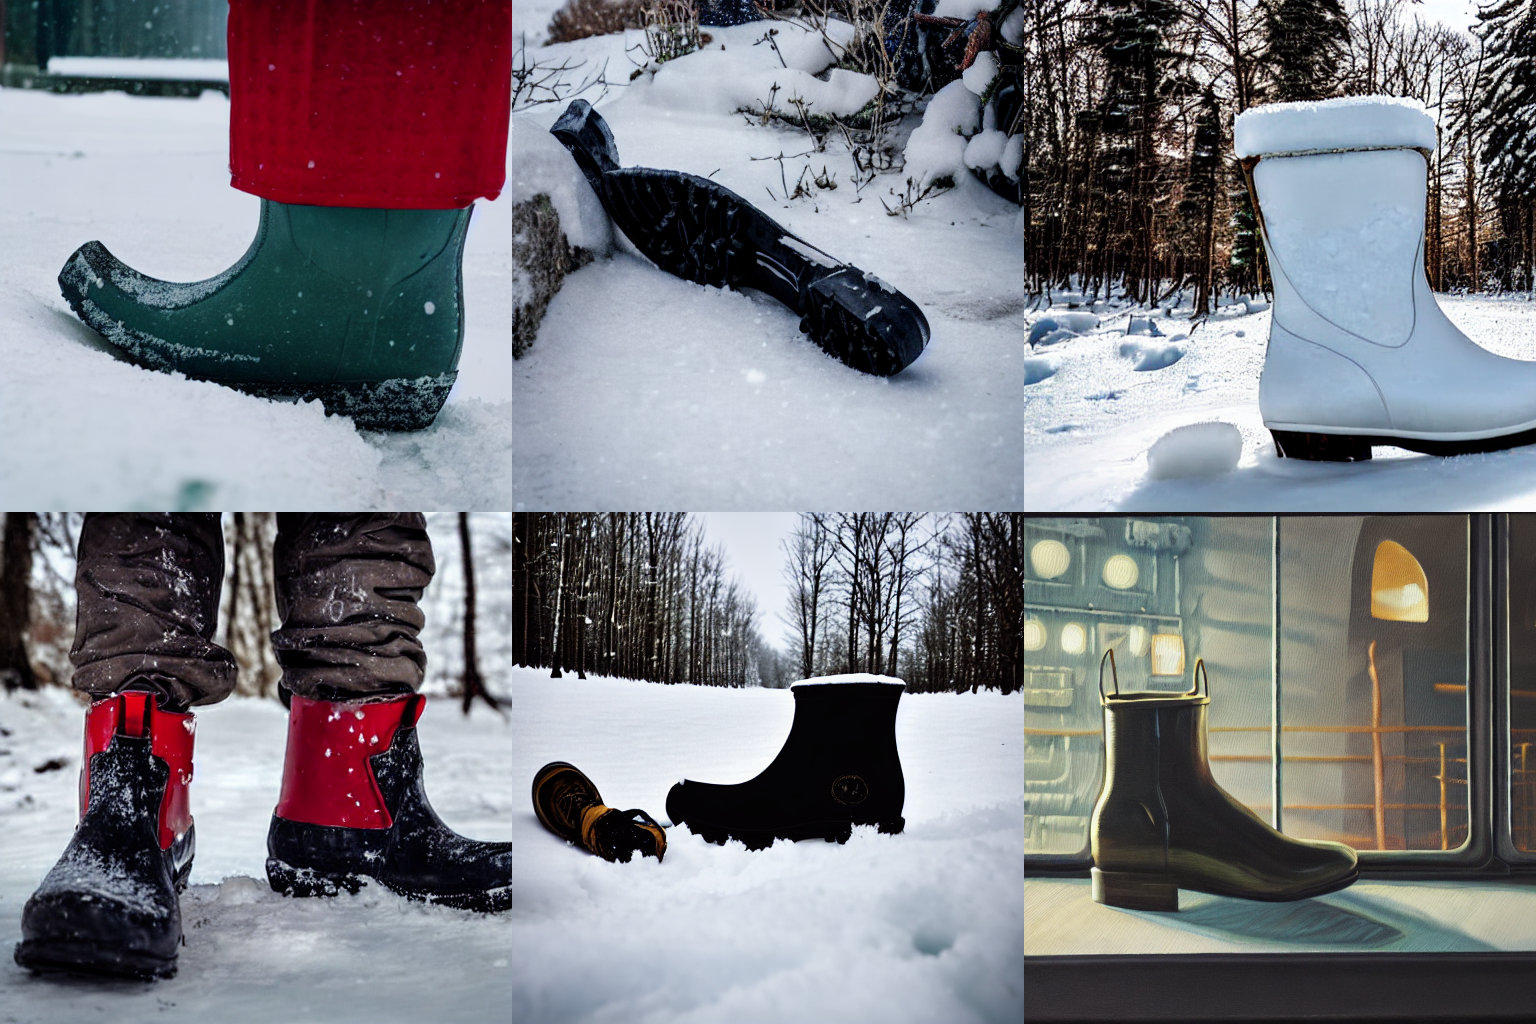

In [14]:
from diffusers import StableDiffusionPipeline
import torch
from PIL import Image

def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols
    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

model_path = "runwayml/stable-diffusion-v1-5"
lora_path = args.output_dir

pipe = StableDiffusionPipeline.from_pretrained(model_path, torch_dtype=torch.float16)
pipe.load_lora_weights(lora_path)
pipe.to("cuda")

experiments = [
    {
        "name": "exp1_steps_30",
        "prompt": "a photo of a sks boot in the snow",
        "guidance": 7.5,
        "steps": 30,
        "desc": "Steps: 30 (Fast)"
    },
    {
        "name": "exp2_steps_50",
        "prompt": "a photo of a sks boot in the snow",
        "guidance": 7.5,
        "steps": 50,
        "desc": "Steps: 50 (Standard)"
    },
    {
        "name": "exp3_steps_100",
        "prompt": "a photo of a sks boot in the snow",
        "guidance": 7.5,
        "steps": 100,
        "desc": "Steps: 100 (High Quality)"
    },
    {
        "name": "exp4_guidance_5",
        "prompt": "a photo of a sks boot in the snow",
        "guidance": 5.0,
        "steps": 50,
        "desc": "Guidance: 5.0 (Creative)"
    },
    {
        "name": "exp5_guidance_10",
        "prompt": "a photo of a sks boot in the snow",
        "guidance": 10.0,
        "steps": 50,
        "desc": "Guidance: 10.0 (Strict)"
    },
    {
        "name": "exp6_complex",
        "prompt": "oil painting of a sks boot inside a futuristic museum, intricate lighting",
        "guidance": 7.5,
        "steps": 50,
        "desc": "Complex Prompt"
    }
]

generated_images = []

for exp in experiments:
    print(f"Running {exp['desc']}...")
    image = pipe(
        exp["prompt"],
        num_inference_steps=exp["steps"],
        guidance_scale=exp["guidance"]
    ).images[0]

    filename = f"{exp['name']}.png"
    image.save(filename)
    generated_images.append(image)
    print(f"Saved {filename}")

try:
    grid = image_grid(generated_images, 2, 3)
    display(grid)
    grid.save("final_grid_report.png")
except Exception as e:
    for img in generated_images:
        display(img)